# Trabalho 1 de Ciência de Dados
## estatística descritiva: contextualização e análise descritiva

Universidade de Fortaleza - T326. Equipe: Luma, Amanda, Peter e Luís.

**Pergunta-guia: “O Brasil é um país desigual?”**

As diferenças de produção econômica entre municípios constituem uma dimensão
territorial da desigualdade. Esta seção investiga essa dimensão nos municípios
do Sudeste, sem tomar o PIB como medida suficiente de bem-estar ou da distribuição
da renda entre pessoas. O objetivo social é oferecer uma leitura acessível de dados
públicos que contribua para o debate informado sobre disparidades territoriais.
Esse objetivo não comprova que tenha ocorrido uma ação extensionista.

O objetivo analítico é descrever o PIB per capita municipal, identificar os cinco
maiores e menores valores de PIB total e por habitante e visualizar a distribuição.
Trata-se de estudo quantitativo, descritivo e transversal, com dados secundários.
Não se estimam relações causais nem se generalizam os resultados ao Brasil inteiro.

## Fontes, período e unidade de análise

A unidade de análise é **um município em 2020**. O recorte reúne Espírito Santo,
Minas Gerais, Rio de Janeiro e São Paulo, conforme a DTB fornecida à equipe.

| Fonte documentada por preparação dos dados | Arquivo original | Referência e uso |
|---|---|---|
| IBGE/SIDRA, tabela 5938 | tabela5938_2020.csv.xz | 2020; PIB municipal |
| IBGE/SIDRA, tabela 6579 | tabela6579_2020.csv.xz | 2020; estimativa de população residente |
| Divisão Territorial Brasileira/IBGE | RELATORIO_DTB_BRASIL_MUNICIPIO.csv | Edição não informada; códigos, nomes e UFs |

O ano de PIB e população foi identificado por preparação dos dados nos nomes originais, confirmados
pelo título no Drive e por Content-Disposition. Os CSVs originais não trazem coluna
de ano. A edição desconhecida da DTB impede afirmar equivalência histórica dos
limites territoriais apenas pela correspondência de códigos.

Esta seção lê `data/processed/sudeste_municipios.parquet`, preservando a base e os
notebooks originais. As unidades são reais correntes de 2020 para PIB total,
pessoas para população e reais por pessoa para PIB per capita. Não se aplicam
deflatores nem atualizações monetárias.

Documentação consultada: os dois notebooks `01_preparacao_dados`,
`data/processed/metadados.json`, `docs/dicionario_dados.md`,
`outputs/reports/qualidade.md` e `qualidade.json`. Os arquivos brutos e todas as
auditorias intermediárias não estão nesta cópia do repositório; o tratamento
anterior é descrito a partir desses registros, sem alegar nova execução dessa etapa.

## Preparação dos dados

A etapa de preparação inspecionou as fontes, leu inicialmente os campos como texto, padronizou
nomes de variáveis e preservou o código IBGE completo de sete dígitos como chave.
Converteu os campos monetários de mil reais para reais, multiplicando por 1.000,
e realizou cruzamentos um para um pelo código municipal. O recorte territorial
deriva dos códigos de UF 31, 32, 33 e 35. Os nomes municipais adotados são os da DTB.

O pipeline documentado interrompe a preparação quando encontra chaves inválidas
ou duplicadas. PIB ausente, negativo ou não finito e população ausente, não positiva,
não inteira ou não finita inviabilizam o cálculo e são objeto de exclusão auditada,
sem imputação. Impostos e valores adicionados foram preservados segundo as regras
documentadas por preparação dos dados, mas não são analisados nesta seção.

A etapa de preparação calculou **PIB per capita = PIB total em reais / população em pessoas**, com
PIB e população do mesmo ano. O relatório registra 5.570 linhas em cada fonte,
3.902 municípios fora do recorte e 1.668 no Sudeste. Não houve perdas nos cruzamentos,
exclusões por cálculo inválido, duplicatas, divergências de nomes ou valores ausentes
na base final. A seguir, A seção descritiva confere a base de consumo sem refazer a preparação.

In [1]:
from pathlib import Path
import hashlib
import json
import math
import statistics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter
from IPython.display import display, Markdown, HTML

# Prefixo am_ evita conflitos com outras contribuições na integração.
am_raiz = next((p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / 'data/processed/metadados.json').is_file()), None)
if am_raiz is None:
    raise FileNotFoundError('Execute dentro do projeto com a base tratada da preparação dos dados.')
am_entrada = am_raiz / 'data/processed/sudeste_municipios.parquet'
am_hash_antes = hashlib.sha256(am_entrada.read_bytes()).hexdigest()
am_dados = pd.read_parquet(am_entrada).copy(deep=True)
am_meta = json.loads((am_raiz / 'data/processed/metadados.json').read_text())
am_qualidade = json.loads((am_raiz / 'outputs/reports/qualidade.json').read_text())
am_saida = am_raiz / 'outputs/estatistica_descritiva'
am_tabelas = am_saida / 'tabelas'
am_figuras = am_raiz / 'outputs/figures'
for am_pasta in [am_saida, am_tabelas, am_figuras]:
    am_pasta.mkdir(parents=True, exist_ok=True)

def am_br(valor, casas=2):
    return f'{valor:,.{casas}f}'.replace(',', '_').replace('.', ',').replace('_', '.')

def am_mostrar(tabela, numericas=()):
    # Apenas a exibição é arredondada; CSVs mantêm a precisão numérica.
    copia = tabela.copy()
    for coluna in numericas:
        copia[coluna] = copia[coluna].map(am_br)
    copia = copia.rename(columns={'posicao': 'Pos.', 'municipio': 'Município',
        'uf': 'UF', 'valor': 'Valor', 'unidade': 'Unidade',
        'medida': 'Medida', 'indicador': 'Indicador', 'municipios': 'Municípios'})
    display(HTML(copia.to_html(index=False, escape=True, border=0)))

assert set(am_dados['uf']) == {'ES', 'MG', 'RJ', 'SP'}
assert am_dados['ano'].eq(2020).all() and am_meta['ano_selecionado'] == 2020
assert am_dados['regiao'].eq('Sudeste').all()
assert not am_dados.duplicated(['codigo_municipio', 'ano']).any()
assert am_dados['codigo_municipio'].str.fullmatch(r'\d{7}').all()
assert not am_dados[['municipio', 'uf']].isna().any().any()
am_cobertura = am_dados.groupby('uf').size().rename('municipios').reset_index()
assert am_cobertura.set_index('uf')['municipios'].to_dict() == dict(
    am_qualidade['registros_por_uf_final'])
am_cobertura.to_csv(am_tabelas / 'cobertura.csv', index=False)
am_mostrar(am_cobertura)
print('Registros na base:', len(am_dados), '| Duplicatas município/ano: 0')

Matplotlib is building the font cache; this may take a moment.


UF,Municípios
ES,78
MG,853
RJ,92
SP,645


Registros na base: 1668 | Duplicatas município/ano: 0


## Validade e exclusões nesta seção

Valores ausentes, não finitos ou negativos de PIB total e per capita não entram nas
respectivas estatísticas ou rankings. Zero, se existisse, seria mantido nessas
análises. A população precisa ser inteira e positiva para o agregado regional.
Não há imputação nem exclusão automática de extremos. Registros inválidos, caso
existam, ficam identificados no CSV de auditoria. A escala logarítmica exige valores
estritamente positivos; essa restrição se aplica apenas ao histograma.

In [2]:
am_auditoria = []
am_validas = {}
am_exclusoes = []
for am_col in ['pib_total_reais', 'pib_per_capita_reais', 'populacao']:
    am_s = am_dados[am_col].astype(float)
    am_finito = pd.Series(np.isfinite(am_s), index=am_s.index)
    am_invalido_dominio = (am_s <= 0) | (am_s % 1 != 0) if am_col == 'populacao' else am_s < 0
    am_ok = am_finito & ~am_invalido_dominio
    am_validas[am_col] = am_ok
    am_auditoria.append({'variavel': am_col, 'ausentes': int(am_s.isna().sum()),
        'nao_finitos_sem_nulos': int((~am_finito & am_s.notna()).sum()),
        'dominio_invalido_finito': int((am_finito & am_invalido_dominio).sum()),
        'validos': int(am_ok.sum()), 'excluidos': int((~am_ok).sum())})
    for am_i in am_s.index[~am_ok]:
        am_exclusoes.append({'codigo_municipio': am_dados.loc[am_i, 'codigo_municipio'],
            'municipio': am_dados.loc[am_i, 'municipio'], 'uf': am_dados.loc[am_i, 'uf'],
            'variavel': am_col, 'valor': am_s.loc[am_i],
            'motivo': 'ausente' if pd.isna(am_s.loc[am_i]) else
                      ('nao finito' if not am_finito.loc[am_i] else 'dominio invalido')})
am_auditoria = pd.DataFrame(am_auditoria)
am_auditoria.to_csv(am_tabelas / 'auditoria_validade.csv', index=False)
pd.DataFrame(am_exclusoes, columns=['codigo_municipio', 'municipio', 'uf',
    'variavel', 'valor', 'motivo']).to_csv(am_tabelas / 'exclusoes.csv', index=False)
am_mostrar(am_auditoria)
am_par = am_validas['pib_total_reais'] & am_validas['populacao']
np.testing.assert_allclose(
    am_dados.loc[am_par, 'pib_per_capita_reais'].astype(float),
    (am_dados.loc[am_par, 'pib_total_reais'] / am_dados.loc[am_par, 'populacao']).astype(float),
    rtol=1e-12, atol=1e-8)
am_x = am_dados.loc[am_validas['pib_per_capita_reais'], 'pib_per_capita_reais'].astype(float)
assert len(am_x) > 0
display(Markdown(f'Conferência da base: **{len(am_x)} observações válidas** de PIB per capita. '
    f'Exclusões nesta variável: **{len(am_dados) - len(am_x)}**. '
    'A fórmula de PIB per capita confere com PIB total dividido pela população.'))

variavel,ausentes,nao_finitos_sem_nulos,dominio_invalido_finito,validos,excluidos
pib_total_reais,0,0,0,1668,0
pib_per_capita_reais,0,0,0,1668,0
populacao,0,0,0,1668,0


Conferência da base: **1668 observações válidas** de PIB per capita. Exclusões nesta variável: **0**. A fórmula de PIB per capita confere com PIB total dividido pela população.

## Estatística descritiva do PIB per capita

Cada município tem o mesmo peso. A média simples é a soma dos valores municipais
dividida pelo número de municípios válidos. A mediana divide a distribuição ordenada
ao meio. Q1 e Q3 delimitam os 50% centrais. Usam-se quantis com **interpolação linear**
do pandas, equivalente ao método linear do NumPy (posição `(n - 1) × p`).

A variância e o desvio padrão são **populacionais**, com `ddof=0` e divisor **N**,
pois descrevemos o universo municipal coberto pela base, e não uma amostra aleatória.
Variância = soma dos desvios quadráticos em relação à média / N; desvio padrão =
raiz quadrada da variância. Essa convenção não elimina as limitações das fontes.
A variância fica em (R$/pessoa)²; o desvio padrão mantém a unidade R$/pessoa.

Amplitude = máximo - mínimo. Intervalo interquartil (IIQ) = Q3 - Q1.
Coeficiente de variação (CV) = 100 × desvio padrão / média, calculado quando a média
é positiva. Ele expressa dispersão relativa, não um índice de desigualdade da renda
individual. Nenhuma medida é calculada a partir de valores previamente arredondados.

In [3]:
am_q1, am_q2, am_q3 = am_x.quantile([0.25, 0.50, 0.75], interpolation='linear')
am_media, am_dp = am_x.mean(), am_x.std(ddof=0)
am_cv = 100 * am_dp / am_media if am_media > 0 else np.nan
am_estat = pd.DataFrame([
    ('Observações válidas', len(am_x), 'municípios'),
    ('Média simples', am_media, 'R$/pessoa'),
    ('Mediana (Q2)', am_q2, 'R$/pessoa'),
    ('Mínimo', am_x.min(), 'R$/pessoa'),
    ('Máximo', am_x.max(), 'R$/pessoa'),
    ('Primeiro quartil (Q1)', am_q1, 'R$/pessoa'),
    ('Terceiro quartil (Q3)', am_q3, 'R$/pessoa'),
    ('Amplitude', am_x.max() - am_x.min(), 'R$/pessoa'),
    ('Variância populacional', am_x.var(ddof=0), '(R$/pessoa)²'),
    ('Desvio padrão populacional', am_dp, 'R$/pessoa'),
    ('Intervalo interquartil', am_q3 - am_q1, 'R$/pessoa'),
    ('Coeficiente de variação', am_cv, '%'),
], columns=['medida', 'valor', 'unidade'])
am_estat.to_csv(am_tabelas / 'estatisticas_pib_per_capita.csv', index=False)
am_mostrar(am_estat, ['valor'])
display(Markdown(
    f'A média é **R$ {am_br(am_media)} por pessoa**, enquanto a mediana é '
    f'**R$ {am_br(am_q2)}**. A média supera a mediana em '
    f'**{am_br((am_media / am_q2 - 1) * 100)}%**: valores elevados puxam a média '
    'para cima, de modo que ela não descreve sozinha o município central. '
    f'Os 50% centrais situam-se aproximadamente entre **R$ {am_br(am_q1)}** '
    f'e **R$ {am_br(am_q3)}**, com IIQ de **R$ {am_br(am_q3 - am_q1)}**.\n\n'
    f'O desvio padrão de **R$ {am_br(am_dp)}** é próximo à própria média, '
    f'e o CV é **{am_br(am_cv)}%**, indicando grande heterogeneidade municipal. '
    f'O mínimo é **R$ {am_br(am_x.min())}** e o máximo **R$ {am_br(am_x.max())}**, '
    f'uma razão de **{am_br(am_x.max() / am_x.min(), 1)} vezes**. '
    'Amplitude e variância são sensíveis a esses extremos; o IIQ complementa '
    'a leitura da dispersão ao focalizar a metade central dos municípios.'))

Medida,Valor,Unidade
Observações válidas,"1.668,00",municípios
Média simples,"30.364,89",R$/pessoa
Mediana (Q2),"22.531,00",R$/pessoa
Mínimo,"6.509,54",R$/pessoa
Máximo,"357.104,23",R$/pessoa
Primeiro quartil (Q1),"15.577,63",R$/pessoa
Terceiro quartil (Q3),"34.683,50",R$/pessoa
Amplitude,"350.594,69",R$/pessoa
Variância populacional,"952.058.409,68",(R$/pessoa)²
Desvio padrão populacional,"30.855,44",R$/pessoa


A média é **R$ 30.364,89 por pessoa**, enquanto a mediana é **R$ 22.531,00**. A média supera a mediana em **34,77%**: valores elevados puxam a média para cima, de modo que ela não descreve sozinha o município central. Os 50% centrais situam-se aproximadamente entre **R$ 15.577,63** e **R$ 34.683,50**, com IIQ de **R$ 19.105,87**.

O desvio padrão de **R$ 30.855,44** é próximo à própria média, e o CV é **101,62%**, indicando grande heterogeneidade municipal. O mínimo é **R$ 6.509,54** e o máximo **R$ 357.104,23**, uma razão de **54,9 vezes**. Amplitude e variância são sensíveis a esses extremos; o IIQ complementa a leitura da dispersão ao focalizar a metade central dos municípios.

## Média municipal e PIB per capita regional

A média simples responde qual é o valor médio **entre municípios**, dando o mesmo
peso a todos. O PIB per capita regional responde qual é a produção agregada por
habitante do recorte: **soma dos PIBs / soma das populações**, sempre sobre o mesmo
conjunto de municípios. Ele equivale à média dos PIBs per capita municipais ponderada
pela população. Não se deve somar os PIBs per capita, nem apresentar a média simples
como PIB per capita do Sudeste. O cálculo abaixo confere a cobertura comum.

In [4]:
am_agregado = am_dados.loc[am_par]
am_pib_soma = float(am_agregado['pib_total_reais'].sum())
am_pop_soma = int(am_agregado['populacao'].sum())
am_regional = am_pib_soma / am_pop_soma
am_ponderada = np.average(am_agregado['pib_per_capita_reais'].astype(float),
    weights=am_agregado['populacao'].astype(float))
np.testing.assert_allclose(am_regional, am_ponderada, rtol=1e-12)
am_comparacao = pd.DataFrame([
    ('Municípios no agregado', len(am_agregado), 'municípios'),
    ('PIB total do recorte', am_pib_soma, 'R$ correntes de 2020'),
    ('População total do recorte', am_pop_soma, 'pessoas'),
    ('Média simples municipal', am_media, 'R$/pessoa'),
    ('PIB per capita regional', am_regional, 'R$/pessoa'),
], columns=['indicador', 'valor', 'unidade'])
am_comparacao.to_csv(am_tabelas / 'media_municipal_e_regional.csv', index=False)
am_mostrar(am_comparacao, ['valor'])
display(Markdown(f'O agregado inclui **{len(am_agregado)} municípios** e '
    f'**{am_br(am_pop_soma, 0)} pessoas**. O PIB per capita regional é '
    f'**R$ {am_br(am_regional)}**, frente a **R$ {am_br(am_media)}** na média simples. '
    'A diferença decorre dos pesos populacionais: cada município contribui para '
    'o agregado de acordo com sua população. Ambos descrevem produção, não renda recebida.'))

Indicador,Valor,Unidade
Municípios no agregado,"1.668,00",municípios
PIB total do recorte,"3.952.694.732.000,00",R$ correntes de 2020
População total do recorte,"89.012.240,00",pessoas
Média simples municipal,"30.364,89",R$/pessoa
PIB per capita regional,"44.406,19",R$/pessoa


O agregado inclui **1668 municípios** e **89.012.240 pessoas**. O PIB per capita regional é **R$ 44.406,19**, frente a **R$ 30.364,89** na média simples. A diferença decorre dos pesos populacionais: cada município contribui para o agregado de acordo com sua população. Ambos descrevem produção, não renda recebida.

## Rankings municipais

Os rankings usam valores válidos da respectiva variável, antes do arredondamento.
Top 5 ordena do maior para o menor; Bottom 5, do menor para o maior. Em empate
numérico exato, o **código IBGE completo em ordem crescente** desempata. São exibidas
exatamente cinco linhas, mesmo em empate na quinta posição; o número de empatados
nesse limite é informado. A posição indica a ordem de exibição, não uma diferença
econômica entre valores empatados. Valores exibidos iguais após arredondamento
não são necessariamente empates reais. Todos os valores monetários referem-se a 2020.

In [5]:
am_rankings = {}
am_empates = []
for am_col, am_rotulo, am_unidade in [
    ('pib_total_reais', 'PIB total', 'R$ correntes de 2020'),
    ('pib_per_capita_reais', 'PIB per capita', 'R$/pessoa em 2020')]:
    for am_tipo, am_asc in [('top5', False), ('bottom5', True)]:
        am_ordem = am_dados.loc[am_validas[am_col]].sort_values(
            [am_col, 'codigo_municipio'], ascending=[am_asc, True], kind='stable')
        am_cinco = am_ordem.head(5)
        am_limite = am_cinco[am_col].iloc[-1]
        am_total_empatados = int(am_ordem[am_col].eq(am_limite).sum())
        am_fora = am_total_empatados - int(am_cinco[am_col].eq(am_limite).sum())
        am_nome = f'{am_tipo}_{am_col}'
        am_t = am_cinco[['codigo_municipio', 'municipio', 'uf', 'ano', am_col]].copy()
        am_t = am_t.rename(columns={am_col: 'valor'}).reset_index(drop=True)
        am_t.insert(0, 'posicao', range(1, len(am_t) + 1))
        am_t['unidade'] = am_unidade
        am_rankings[am_nome] = am_t
        am_t.to_csv(am_tabelas / f'{am_nome}.csv', index=False)
        display(Markdown(f'### {"Top 5" if not am_asc else "Bottom 5"}: {am_rotulo}'))
        am_mostrar(am_t[['posicao', 'municipio', 'uf', 'valor', 'unidade']], ['valor'])
        am_empates.append({'ranking': am_nome, 'municipios_no_valor_limite':
            am_total_empatados, 'empatados_fora_das_cinco_linhas': am_fora})
        print(f'Excluídos por valor inválido: {int((~am_validas[am_col]).sum())}. '
              f'Municípios com o valor da 5ª posição: {am_total_empatados}; '
              f'empatados fora da tabela: {am_fora}.')
pd.DataFrame(am_empates).to_csv(am_tabelas / 'empates_rankings.csv', index=False)
am_top_total = am_rankings['top5_pib_total_reais'].iloc[0]
am_top_pc = am_rankings['top5_pib_per_capita_reais'].iloc[0]
am_bottom_pc = am_rankings['bottom5_pib_per_capita_reais'].iloc[0]
display(Markdown(f'**{am_top_total.municipio} ({am_top_total.uf})** lidera em PIB total, '
    f'com **R$ {am_br(am_top_total.valor)}**. Em PIB per capita, o primeiro é '
    f'**{am_top_pc.municipio} ({am_top_pc.uf})**, com **R$ {am_br(am_top_pc.valor)} por pessoa**; '
    f'o menor valor é o de **{am_bottom_pc.municipio} ({am_bottom_pc.uf})**, '
    f'**R$ {am_br(am_bottom_pc.valor)} por pessoa**. A mudança de liderança mostra '
    'que volume de produção e produção por habitante descrevem aspectos distintos. '
    'Os rankings não identificam, por si sós, a renda ou o bem-estar dos moradores.'))

### Top 5: PIB total

Pos.,Município,UF,Valor,Unidade
1,São Paulo,SP,"748.759.007.000,00",R$ correntes de 2020
2,Rio de Janeiro,RJ,"331.279.902.000,00",R$ correntes de 2020
3,Belo Horizonte,MG,"97.509.893.000,00",R$ correntes de 2020
4,Osasco,SP,"76.311.814.000,00",R$ correntes de 2020
5,Guarulhos,SP,"65.849.311.000,00",R$ correntes de 2020


Excluídos por valor inválido: 0. Municípios com o valor da 5ª posição: 1; empatados fora da tabela: 0.


### Bottom 5: PIB total

Pos.,Município,UF,Valor,Unidade
1,Serra da Saudade,MG,"21.055.000,00",R$ correntes de 2020
2,Passabém,MG,"21.854.000,00",R$ correntes de 2020
3,Cedro do Abaeté,MG,"22.133.000,00",R$ correntes de 2020
4,São Sebastião do Rio Preto,MG,"23.463.000,00",R$ correntes de 2020
5,Paiva,MG,"25.856.000,00",R$ correntes de 2020


...

Excluídos por valor inválido: 0. Municípios com o valor da 5ª posição: 1; empatados fora da tabela: 0.


### Bottom 5: PIB per capita

Pos.,Município,UF,Valor,Unidade
1,Francisco Badaró,MG,"6.509,54",R$/pessoa em 2020
2,Chapada do Norte,MG,"6.802,93",R$/pessoa em 2020
3,São João das Missões,MG,"6.855,16",R$/pessoa em 2020
4,Ladainha,MG,"7.306,38",R$/pessoa em 2020
5,Cônego Marinho,MG,"7.655,74",R$/pessoa em 2020


Excluídos por valor inválido: 0. Municípios com o valor da 5ª posição: 1; empatados fora da tabela: 0.


**São Paulo (SP)** lidera em PIB total, com **R$ 748.759.007.000,00**. Em PIB per capita, o primeiro é **Louveira (SP)**, com **R$ 357.104,23 por pessoa**; o menor valor é o de **Francisco Badaró (MG)**, **R$ 6.509,54 por pessoa**. A mudança de liderança mostra que volume de produção e produção por habitante descrevem aspectos distintos. Os rankings não identificam, por si sós, a renda ou o bem-estar dos moradores.

## Histograma do PIB per capita municipal

O histograma usa **eixo horizontal logarítmico de base 10**, com classes igualmente
espaçadas no logaritmo, mas rótulos em reais por pessoa. Assim, distâncias iguais
representam razões iguais. Essa escolha permite visualizar valores menores sem
ocultar a cauda de valores elevados. A frequência vertical é a contagem de
municípios por intervalo multiplicativo, não densidade por real.

O número de classes é determinado pela regra de Freedman-Diaconis aplicada ao
log10 dos valores positivos: largura = 2 × IIQ(log10) / n^(1/3). As bordas cobrem
todo o intervalo observado; os intervalos são fechados à esquerda e abertos à direita,
exceto o último, que inclui a borda direita. Os valores originais permanecem intactos.
Zeros e negativos não podem aparecer no log: seriam contados e informados
separadamente, sem somar constantes artificiais. Não se retiram extremos válidos.

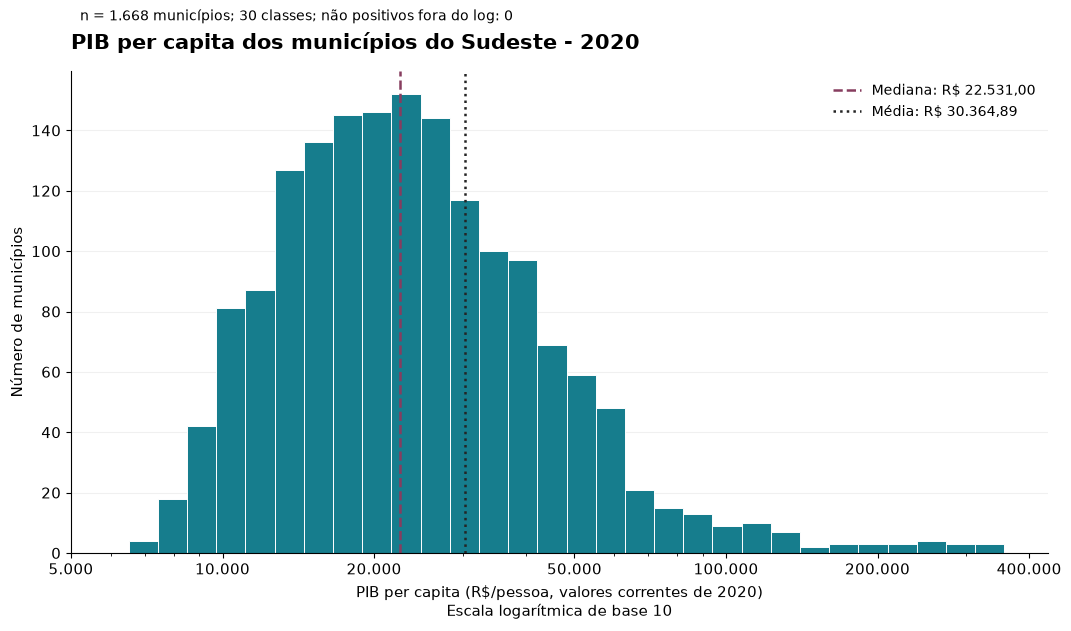

Fonte: base tratada na etapa de preparação, com PIB e população IBGE de 2020. Foram representados **1668 municípios**, com **0 valores válidos não positivos fora do log**.

A classe mais frequente contém **152 municípios**, entre **R$ 21.643,32** e **R$ 24.734,25** por pessoa. Os 50% centrais ficam entre R$ 15.577,63 e R$ 34.683,50. Apenas **42 municípios (2,52%)** superam R$ 100.000 por pessoa, formando a cauda de valores elevados. O máximo de R$ 357.104,23 foi mantido. Na escala original, a distância entre média e mediana e a extensão da cauda à direita evidenciam concentração de municípios em valores inferiores aos extremos. O log comprime as distâncias altas; a aparência do gráfico não deve ser interpretada como igualdade de distâncias monetárias nem como prova de normalidade.

In [6]:
am_positivos = am_x[am_x > 0]
am_nao_positivos = int((am_x <= 0).sum())
assert len(am_positivos) > 0
am_log = np.log10(am_positivos.to_numpy())
am_bordas_log = np.histogram_bin_edges(am_log, bins='fd')
am_bordas = np.power(10.0, am_bordas_log)
# Compensa apenas erro de ponto flutuante nas duas extremidades.
am_bordas[0] = min(am_bordas[0], float(am_positivos.min()))
am_bordas[-1] = max(am_bordas[-1], float(am_positivos.max()))
am_freq, _ = np.histogram(am_positivos, bins=am_bordas)
assert int(am_freq.sum()) == len(am_positivos)
pd.DataFrame({'limite_inferior_reais_pessoa': am_bordas[:-1],
    'limite_superior_reais_pessoa': am_bordas[1:], 'municipios': am_freq,
    'inclui_limite_superior': [False] * (len(am_freq) - 1) + [True]
}).to_csv(am_tabelas / 'classes_histograma.csv', index=False)

with plt.rc_context({'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False}):
    am_fig, am_ax = plt.subplots(figsize=(10.6, 6.2), layout='constrained')
    am_ax.hist(am_positivos, bins=am_bordas, color='#167D8D',
               edgecolor='white', linewidth=0.7)
    am_ax.set_xscale('log')
    am_ax.set_xticks([5000, 10000, 20000, 50000, 100000, 200000, 400000])
    am_ax.xaxis.set_major_formatter(FuncFormatter(lambda v, p: am_br(v, 0)))
    am_ax.xaxis.set_minor_formatter(NullFormatter())
    am_ax.axvline(am_q2, color='#873D5F', linestyle='--', linewidth=1.8,
                  label=f'Mediana: R$ {am_br(am_q2)}')
    am_ax.axvline(am_media, color='#242424', linestyle=':', linewidth=1.8,
                  label=f'Média: R$ {am_br(am_media)}')
    am_ax.set_title('PIB per capita dos municípios do Sudeste - 2020',
                    loc='left', fontsize=15, fontweight='bold', pad=16)
    am_ax.set_xlabel('PIB per capita (R$/pessoa, valores correntes de 2020)\nEscala logarítmica de base 10')
    am_ax.set_ylabel('Número de municípios')
    am_ax.grid(axis='y', alpha=0.18)
    am_ax.set_axisbelow(True)
    am_ax.legend(frameon=False, fontsize=10)
    am_fig.suptitle(f'n = {len(am_positivos):,}'.replace(',', '.') +
        f' municípios; {len(am_freq)} classes; não positivos fora do log: {am_nao_positivos}',
        x=0.07, ha='left', fontsize=10)
    am_fig.savefig(am_figuras / 'histograma_pib_per_capita.png', dpi=200)
    plt.show()
    plt.close(am_fig)
am_acima100 = int((am_x > 100000).sum())
am_moda_classe = int(am_freq.argmax())
display(Markdown(f'Fonte: base tratada na etapa de preparação, com PIB e população IBGE de 2020. '
    f'Foram representados **{len(am_positivos)} municípios**, com **{am_nao_positivos} '
    'valores válidos não positivos fora do log**.\n\n'
    f'A classe mais frequente contém **{int(am_freq[am_moda_classe])} municípios**, '
    f'entre **R$ {am_br(am_bordas[am_moda_classe])}** e '
    f'**R$ {am_br(am_bordas[am_moda_classe + 1])}** por pessoa. '
    f'Os 50% centrais ficam entre R$ {am_br(am_q1)} e R$ {am_br(am_q3)}. '
    f'Apenas **{am_acima100} municípios ({am_br(100 * am_acima100 / len(am_x))}%)** '
    'superam R$ 100.000 por pessoa, formando a cauda de valores elevados. '
    f'O máximo de R$ {am_br(am_x.max())} foi mantido. '
    'Na escala original, a distância entre média e mediana e a extensão da cauda '
    'à direita evidenciam concentração de municípios em valores inferiores aos extremos. '
    'O log comprime as distâncias altas; a aparência do gráfico não deve ser interpretada '
    'como igualdade de distâncias monetárias nem como prova de normalidade.'))

## Conclusões parciais e limites

As medidas descritivas, os rankings e o histograma mostram diferenças expressivas
de produção econômica por habitante entre os municípios do Sudeste em 2020.
A média acima da mediana e a presença de poucos valores muito elevados recomendam
considerar também quartis e IIQ na descrição do município típico.

**PIB total** expressa a dimensão da produção municipal. **PIB per capita** divide
essa produção pela população estimada e permite uma comparação ajustada ao tamanho
populacional. Contudo, não equivale à renda individual: não informa quanto cada
morador recebe, quem se apropria da produção nem como a renda se distribui dentro
do município. Um PIB per capita alto pode coexistir com desigualdade interna.

Os resultados oferecem evidências de desigualdade econômica **entre municípios do
recorte analisado**. Não bastam para responder, isoladamente, à pergunta sobre o
Brasil inteiro ou para concluir sobre pobreza, qualidade dos serviços ou mecanismos
causais. Isso exigiria outras regiões, indicadores e estratégias de investigação.
O estudo representa um único ano, usa população estimada e valores correntes e
preserva a limitação territorial da DTB sem edição identificada.

Esta é uma contribuição parcial de estatística descritiva. A preparação é de preparação dos dados. Análises
setoriais, correlações e comparações econômicas por UF cabem a análises econômicas; boxplot,
curtose, medidas de assimetria e conclusão geral não são executados aqui.

## Conferência independente e reprodutibilidade

A verificação abaixo compara média, mediana, variância e desvio padrão com a
biblioteca padrão `statistics`; reconstrói os quartis por interpolação linear;
confere CSV/Parquet, totais e rankings por ordenação independente; verifica
frequências do histograma e a preservação do arquivo de entrada.

Dependências de análise: pandas, numpy, pyarrow, matplotlib e IPython.
`matplotlib` é a dependência adicional ao `requirements.txt` da equipe.
Para execução automática: nbformat, nbclient, nbconvert e ipykernel.
As versões efetivamente utilizadas ficam no relatório JSON de conferência.
Os CSVs usam UTF-8, vírgula como separador e ponto decimal. Os códigos IBGE devem
ser lidos como texto. Valores não foram arredondados para a exportação.

In [7]:
am_lista = am_x.tolist()
np.testing.assert_allclose([am_media, am_q2, am_x.var(ddof=0), am_dp],
    [statistics.mean(am_lista), statistics.median(am_lista),
     statistics.pvariance(am_lista), statistics.pstdev(am_lista)], rtol=1e-12)
am_ordenados = sorted(am_lista)
def am_quantil_independente(p):
    pos = (len(am_ordenados) - 1) * p
    baixo, alto = math.floor(pos), math.ceil(pos)
    return am_ordenados[baixo] + (am_ordenados[alto] - am_ordenados[baixo]) * (pos - baixo)
np.testing.assert_allclose([am_q1, am_q2, am_q3],
    [am_quantil_independente(p) for p in [0.25, 0.5, 0.75]], rtol=1e-12)
assert am_pib_soma == math.fsum(am_agregado['pib_total_reais'].astype(float))
assert am_pop_soma == sum(int(v) for v in am_agregado['populacao'])
am_csv = pd.read_csv(am_raiz / 'data/processed/sudeste_municipios.csv',
    dtype={'codigo_municipio': 'string', 'codigo_uf': 'string'})
pd.testing.assert_frame_equal(am_dados.reset_index(drop=True), am_csv,
    check_dtype=False, rtol=1e-12, atol=1e-8)
for am_nome, am_t in am_rankings.items():
    am_col = 'pib_total_reais' if am_nome.endswith('pib_total_reais') else 'pib_per_capita_reais'
    am_sinal = -1 if am_nome.startswith('top5') else 1
    am_registros = am_dados.loc[am_validas[am_col]].to_dict('records')
    am_esperados = sorted(am_registros,
        key=lambda r: (am_sinal * r[am_col], r['codigo_municipio']))[:5]
    assert am_t['codigo_municipio'].tolist() == [r['codigo_municipio'] for r in am_esperados]
    am_lido = pd.read_csv(am_tabelas / f'{am_nome}.csv', dtype={'codigo_municipio': str})
    np.testing.assert_allclose(am_lido['valor'], am_t['valor'], rtol=1e-12)
assert int(am_freq.sum()) + am_nao_positivos == len(am_x)
assert hashlib.sha256(am_entrada.read_bytes()).hexdigest() == am_hash_antes
import importlib.metadata as am_importlib_metadata
am_relatorio = {'status': 'aprovado', 'ano': 2020, 'n': len(am_x),
    'sha256_base_parquet': am_hash_antes, 'variancia_ddof': 0,
    'quantis': 'linear', 'classes_histograma': len(am_freq),
    'nao_positivos_fora_log': am_nao_positivos,
    'verificacoes': ['statistics', 'quartis independentes', 'totais independentes',
        'CSV versus Parquet', 'rankings e releitura', 'contagem histograma', 'hash preservado'],
    'versoes': {p: am_importlib_metadata.version(p) for p in
        ['pandas', 'numpy', 'pyarrow', 'matplotlib', 'nbformat', 'nbclient', 'ipykernel']}}
(am_saida / 'conferencia.json').write_text(
    json.dumps(am_relatorio, ensure_ascii=False, indent=2), encoding='utf-8')
print('Conferências aprovadas. Base preservada. Resultados em outputs/estatistica_descritiva.')

Conferências aprovadas. Base preservada. Resultados em outputs/estatistica_descritiva.


## Referências e pendências

IBGE. PIB dos Municípios, tabela SIDRA 5938. Arquivo de 2020 fornecido à equipe,
identificado nos metadados de preparação dos dados. https://sidra.ibge.gov.br/tabela/5938

IBGE. Estimativas da população, tabela SIDRA 6579. Arquivo de 2020 fornecido à equipe,
identificado nos metadados de preparação dos dados. https://sidra.ibge.gov.br/tabela/6579

IBGE. Divisão Territorial Brasileira. Arquivo fornecido à equipe, edição não
informada. As páginas são referências institucionais documentadas por preparação dos dados;
não foram usadas para atualizar ou substituir a base.

preparação dos dados. Preparação dos dados do Trabalho 1, notebook e documentação presentes no
repositório. Registro de entrega datado de 08/09/2026.

Equipe. Divisão do Trabalho 1, documento de planejamento fornecido por estatística descritiva.
Seu escopo foi usado como contexto; não autoriza publicação, gravação ou execução
das responsabilidades dos demais integrantes.

**Pendências:** confirmar a edição da DTB se essa informação puder ser recuperada;
revisar e integrar a seção com preparação dos dados; confirmar campos e limites do Dreamshaper.
Ações extensionistas, público atendido, datas, participantes externos e impactos
dependem de evidências da equipe e não são afirmados nesta entrega.